# Name:Sisham Maharjan
# Id: 2409266
# Text classification task

# 4.5 Tasks - To - Do: Text Classification Notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install the 'contractions' library
!pip install -q contractions

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
# from nltk.corpus import stopwords # Moved to cleaning cell
# from nltk.stem import WordNetLemmatizer # Moved to cleaning cell
import contractions
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

# --- Load the dataset ---

file_path_dir = '/content/drive/MyDrive/8. Sarcastic or Not Sarcastic Dataset/' # Corrected Directory path
filename = 'sarcastic_headlines.csv'
full_file_path = os.path.join(file_path_dir, filename)

try:
    # List files in the directory to help identify the correct CSV
    print(f"Files in '{file_path_dir}':")
    listed_files = os.listdir(file_path_dir)
    for item in listed_files:
        print(item)

    if filename not in listed_files:
        print(f"Error: '{filename}' was not found in the directory. Please check the list above and update `filename` with the correct name.")
        df = pd.DataFrame() # Create an empty DataFrame to avoid errors later
    else:
        print(f"Attempting to load '{full_file_path}'...")
        df = pd.read_csv(full_file_path)
        print("Dataset loaded successfully. Displaying first 5 rows:")
        display(df.head())
except FileNotFoundError:
    print(f"Error: The directory '{file_path_dir}' was not found or accessible. Please verify the path.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later

TEXT_COLUMN = 'text'
LABEL_COLUMN = 'is_sarcastic' # Common label for sarcasm datasets, adjust if different

if not df.empty and TEXT_COLUMN not in df.columns:
    print(f"Warning: '{TEXT_COLUMN}' column not found. Please adjust `TEXT_COLUMN` to your actual text column name.")
    # Attempt to guess if there's only one object column
    object_cols = df.select_dtypes(include='object').columns.tolist()
    if len(object_cols) == 1:
        TEXT_COLUMN = object_cols[0]
        print(f"Assuming text column is '{TEXT_COLUMN}'.")
    elif len(object_cols) > 1:
        print("Multiple object columns found. Please manually set `TEXT_COLUMN`.")

if not df.empty and LABEL_COLUMN not in df.columns:
    print(f"Warning: '{LABEL_COLUMN}' column not found. Please adjust `LABEL_COLUMN` to your actual label column name.")

Files in '/content/drive/MyDrive/8. Sarcastic or Not Sarcastic Dataset/':
sarcastic_headlines.csv
8.Description Sarcastic or Not Dataset.txt
Attempting to load '/content/drive/MyDrive/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv'...
Dataset loaded successfully. Displaying first 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


Assuming text column is 'headline'.


### Clean the text

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Define stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
# Keep 'not' in stopwords as it changes sentiment
words_to_keep_in_stopwords = {'not', 'no', 'nor', 'neither', 'never', 'none'}
stop_words = stop_words - words_to_keep_in_stopwords

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str): # Handle non-string inputs
        return ""
    text = text.lower() # Lowercase
    text = contractions.fix(text) # Handle contractions

    # Remove URLs, mentions, and hashtags
    text = re.sub(r'https?\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'#\w+', '', text)  # Remove hashtags

    # Remove numbers and special characters
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove special characters

    # Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(cleaned_tokens)

if not df.empty and TEXT_COLUMN in df.columns:
    print("Cleaning text...")
    df['Cleaned_Text'] = df[TEXT_COLUMN].apply(clean_text)
    display(df[[TEXT_COLUMN, 'Cleaned_Text']].head())
else:
    print("Skipping text cleaning: DataFrame is empty or text column is not defined.")

Cleaning text...


,headline,Cleaned_Text
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...


### Visualize the cleaned data and showing top 20 most frequent words

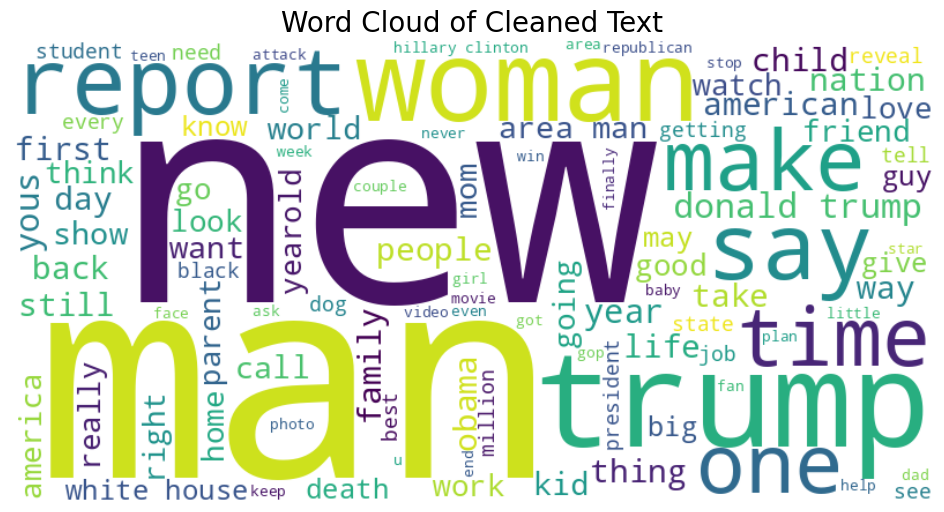

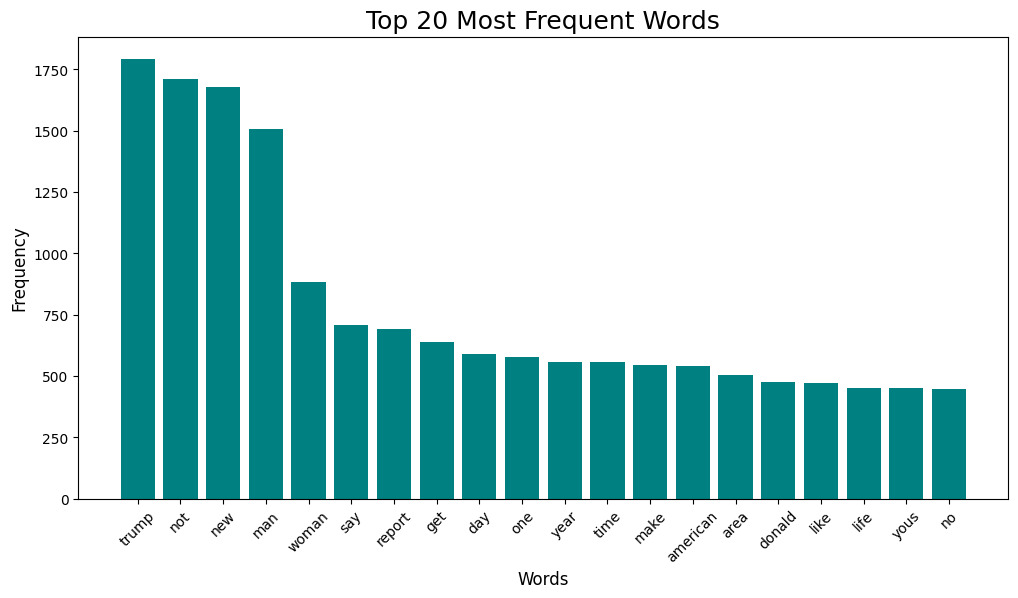

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

if 'df' in globals() and not df.empty and 'Cleaned_Text' in df.columns:
    # Combining all cleaned texts into one string
    all_text = " ".join(review for review in df['Cleaned_Text'])

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400,
                         background_color='white',
                         max_words=100,
                         colormap='viridis').generate(all_text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Cleaned Text', fontsize=20)
    plt.show()
    # Frequency of Words
    words = all_text.split()
    words_counts = Counter(words)
    top_20_words = words_counts.most_common(20)

    # Extract words and counts for plotting
    words_list = [item[0] for item in top_20_words]
    counts_list = [item[1] for item in top_20_words]

    plt.figure(figsize=(12, 6))
    plt.bar(words_list, counts_list, color='teal')
    plt.title('Top 20 Most Frequent Words', fontsize=18)
    plt.xlabel('Words', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Skipping visualization: DataFrame 'df' is not defined, is empty, or 'Cleaned_Text' column is not available.")


Distribution

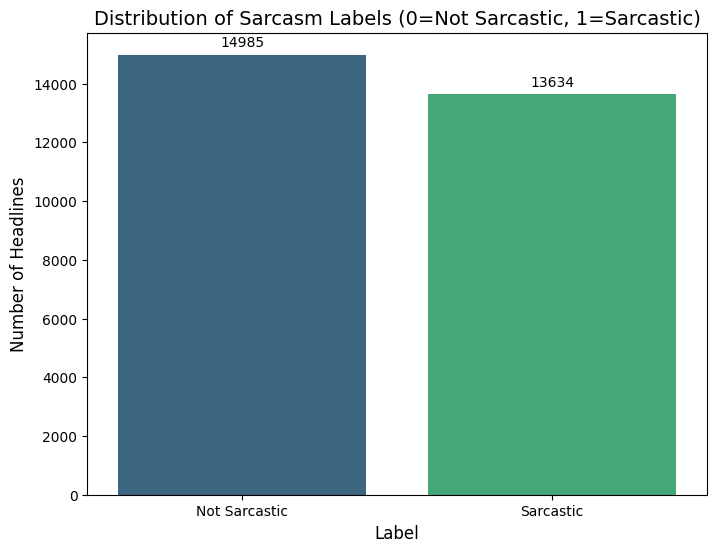

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check the distribution of the 'is_sarcastic' column
label_counts = df['is_sarcastic'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette='viridis', legend=False)

plt.title('Distribution of Sarcasm Labels (0=Not Sarcastic, 1=Sarcastic)', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Number of Headlines', fontsize=12)

# Adding the count labels on top
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.xticks(ticks=[0, 1], labels=['Not Sarcastic', 'Sarcastic']) # Custom x-axis labels
plt.show()

### Tokenization and Padding

Dataset Loaded Successfully!
                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1

Dataset Columns:
Index(['headline', 'is_sarcastic'], dtype='object')

Dataset Shape After Cleaning: (28619, 2)

Sample Cleaned Text:
0    thirtysomething scientists unveil doomsday clo...
1    dem rep totally nails why congress is falling ...
2      eat your veggies  deliciously different recipes
3    inclement weather prevents liar from getting t...
4    mother comes pretty close to using word stream...
Name: Cleaned_Text, dtype: object

Unique Labels: [0 1]

Training Samples: 20605
Validation Samples: 2290
Testing Samples: 5724

Vocabulary Size: 20000
95th Per

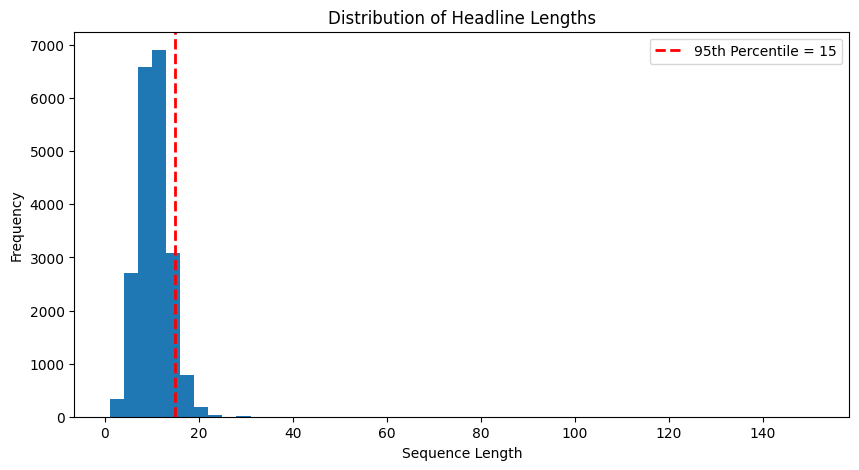


Padding Complete!
Shape of X_train_padded: (20605, 15)
Shape of X_val_padded: (2290, 15)
Shape of X_test_padded: (5724, 15)

Class Weights:
{0: np.float64(0.9549077764389656), 1: np.float64(1.0495619396903015)}

Preprocessing Completed Successfully!


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt



# Load CSV
df = pd.read_csv(full_file_path)

print("Dataset Loaded Successfully!")
print(df.head())

# =========================================================
# CHECK COLUMNS
# =========================================================

print("\nDataset Columns:")
print(df.columns)

# =========================================================
# SELECT TEXT AND LABEL COLUMNS
# =========================================================

# Change these ONLY if your dataset uses different names
TEXT_COLUMN = 'headline'
LABEL_COLUMN = 'is_sarcastic'

# =========================================================
# REMOVE NULL VALUES
# =========================================================

df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna()

print("\nDataset Shape After Cleaning:", df.shape)

# =========================================================
# BASIC TEXT CLEANING
# =========================================================

df['Cleaned_Text'] = (
    df[TEXT_COLUMN]
    .astype(str)
    .str.lower()
    .str.replace(r'[^a-zA-Z\s]', '', regex=True)
    .str.strip()
)

print("\nSample Cleaned Text:")
print(df['Cleaned_Text'].head())

# =========================================================
# SPLIT DATASET
# =========================================================

X = df['Cleaned_Text']
y = df[LABEL_COLUMN]

# Encode labels if needed
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

print("\nUnique Labels:", np.unique(y))

# First Split → Train+Validation and Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second Split → Train and Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1,
    random_state=42,
    stratify=y_temp
)

print(f"\nTraining Samples: {len(X_train)}")
print(f"Validation Samples: {len(X_val)}")
print(f"Testing Samples: {len(X_test)}")

# =========================================================
# TOKENIZATION
# =========================================================

max_words = 20000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

# Convert text into integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Vocabulary Size
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

print("\nVocabulary Size:", vocab_size)

# =========================================================
# ANALYZE SEQUENCE LENGTHS
# =========================================================

sequence_lengths = [len(seq) for seq in X_train_seq]

# Use 95th percentile
maxlen = int(np.percentile(sequence_lengths, 95))

print("95th Percentile Sequence Length:", maxlen)

# =========================================================
# VISUALIZE TEXT LENGTH DISTRIBUTION
# =========================================================

plt.figure(figsize=(10, 5))

plt.hist(sequence_lengths, bins=50)

plt.axvline(
    maxlen,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label=f'95th Percentile = {maxlen}'
)

plt.title("Distribution of Headline Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# =========================================================
# APPLY PADDING
# =========================================================

X_train_padded = pad_sequences(
    X_train_seq,
    maxlen=maxlen,
    padding='post',
    truncating='post'
)

X_val_padded = pad_sequences(
    X_val_seq,
    maxlen=maxlen,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_seq,
    maxlen=maxlen,
    padding='post',
    truncating='post'
)

print("\nPadding Complete!")

print("Shape of X_train_padded:", X_train_padded.shape)
print("Shape of X_val_padded:", X_val_padded.shape)
print("Shape of X_test_padded:", X_test_padded.shape)

# =========================================================
# CLASS WEIGHTS
# =========================================================

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

print("\nClass Weights:")
print(class_weights_dict)

# =========================================================
# FINAL CHECK
# =========================================================

print("\nPreprocessing Completed Successfully!")

## 4.5.2 Model Building and Training

Embedding Layer

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout,
    Input
)

import numpy as np

# =========================================================
# NUMBER OF CLASSES
# =========================================================

num_classes = len(np.unique(y_train))

print(f"Detected Classes: {num_classes}")

# =========================================================
# BUILD SIMPLE RNN MODEL
# =========================================================

rnn_model = Sequential([

    Input(shape=(maxlen,)),

    # Embedding Layer
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # Simple RNN Layer
    SimpleRNN(
        64,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    Dropout(0.5),

    # Dense Layer
    Dense(64, activation='relu'),

    Dropout(0.5),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

# =========================================================
# COMPILE MODEL
# =========================================================

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# MODEL SUMMARY
# =========================================================

rnn_model.summary()

Detected Classes: 2


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ (None, 15, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,576,642 (9.83 MB)

 Trainable params: 2,576,642 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

# Model Building and Training:

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# Save best model
checkpoint = ModelCheckpoint(
    "best_rnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train RNN model
print("Training Simple RNN Model")

rnn_history = rnn_model.fit(
    X_train_padded,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights_dict
)

Training Simple RNN Model
Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5035 - loss: 0.7374
Epoch 1: val_accuracy improved from None to 0.57031, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
644/644 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.5063 - loss: 0.7158 - val_accuracy: 0.5703 - val_loss: 0.6900 - learning_rate: 0.0010
Epoch 2/25
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6143 - loss: 0.6522
Epoch 2: val_accuracy improved from 0.57031 to 0.79738, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
644/644 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.6869 - loss: 0.6063 - val_accuracy: 0.7974 - val_loss: 0.4987 - learning_rate: 0.0010
Epoch 3/25
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8234 - loss: 0.4678
Epoch 3: val_accuracy improved from 0.79738 to 0.84367, saving model to best_rnn_model.keras

Epoch 3: finished saving model to best

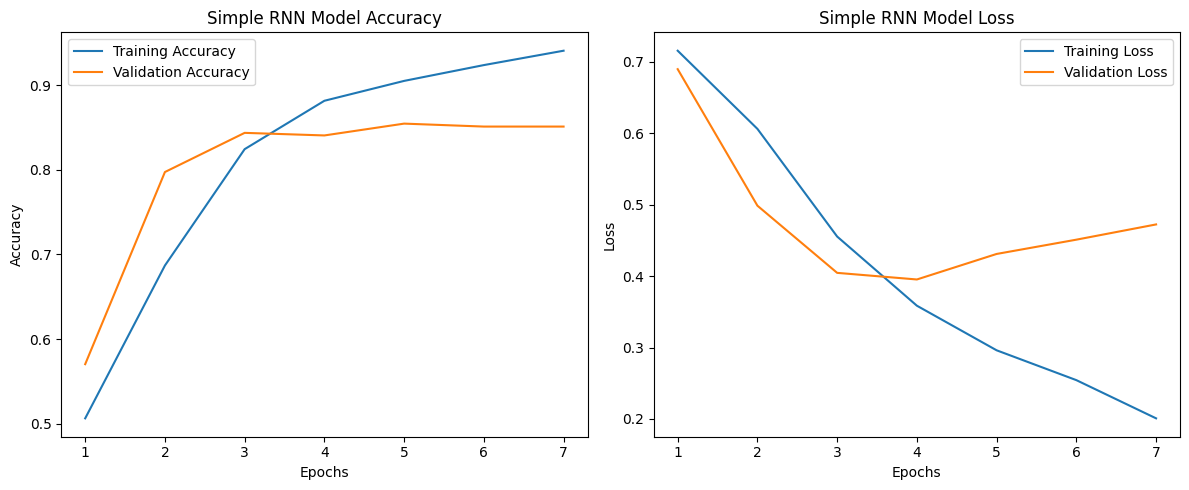

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy graph
    plt.subplot(1, 2, 1)

    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{title} Accuracy")
    plt.legend()

    # Loss graph
    plt.subplot(1, 2, 2)

    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title} Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot RNN training history
plot_history(rnn_history, "Simple RNN Model")

# Model Training and Evaluation:

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Input

# Build Model 2: Bidirectional LSTM
lstm_model = Sequential([

    Input(shape=(maxlen,)),

    Embedding(vocab_size, 128),

    # Bidirectional LSTM layer
    Bidirectional(
        LSTM(
            128,
            dropout=0.3
        )
    ),

    Dense(64, activation='relu'),

    Dropout(0.5),

    # Output layer for sarcasm classification
    Dense(2, activation='softmax')
])

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Model 2: Bidirectional LSTM")

# Model summary
lstm_model.summary()

Training Model 2: Bidirectional LSTM


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 15, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,839,746 (10.83 MB)

 Trainable params: 2,839,746 (10.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7345 - loss: 0.5081
Epoch 1: val_accuracy improved from 0.85459 to 0.86856, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
322/322 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.8034 - loss: 0.4169 - val_accuracy: 0.8686 - val_loss: 0.3046 - learning_rate: 0.0010
Epoch 2/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9296 - loss: 0.1889
Epoch 2: val_accuracy did not improve from 0.86856
322/322 ━━━━━━━━━━━━━━━━━━━━ 39s 115ms/step - accuracy: 0.9246 - loss: 0.1993 - val_accuracy: 0.8603 - val_loss: 0.3046 - learning_rate: 0.0010
Epoch 3/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9681 - loss: 0.0889
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.86856
322/322 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.9637 - loss: 0.0988 - val_accuracy: 0.8563 - val_loss: 0.4011 

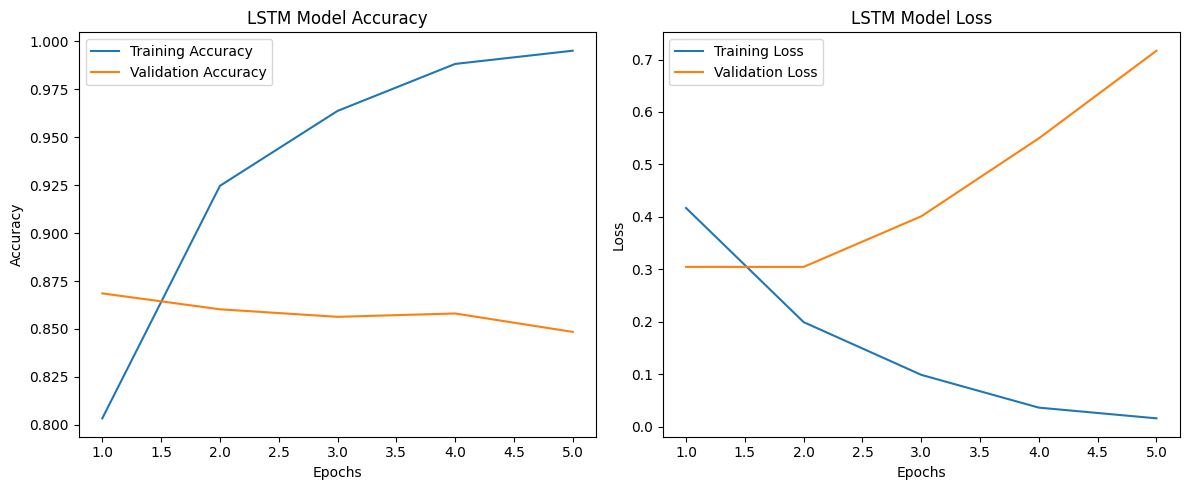

In [ ]:
# Train Model 2: LSTM
lstm_history = lstm_model.fit(
    X_train_padded,
    y_train,

    validation_data=(X_val_padded, y_val),

    epochs=10,
    batch_size=64,

    callbacks=[early_stop, reduce_lr, checkpoint],

    class_weight=class_weights_dict
)

# Plot training results
plot_history(lstm_history, "LSTM Model")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name):

    print(f"\nGenerating predictions for {model_name}...")

    y_pred_probs = model.predict(X_test)

    # Binary classification (sigmoid)
    y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)
    y_true = np.array(y_test).reshape(-1)

    print(f"\n--- {model_name}: Classification Report ---")

    target_names = ['Not Sarcastic', 'Sarcastic']

    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=target_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
rnn_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [ ]:
import gensim.downloader as api

# Downloading GloVe/Word2Vec vectors (50-dimensional is common for student projects)
word2vec = api.load("glove-wiki-gigaword-100")

In [ ]:
# Pretrained embedding setup (Word2Vec / GloVe)
embedding_dim = 100

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Map words to pretrained vectors
for word, i in tokenizer.word_index.items():

    if i < vocab_size:

        if word in word2vec:
            embedding_matrix[i] = word2vec[word]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, Input

# Model 3: LSTM with Pretrained Embeddings
model3 = Sequential([

    Input(shape=(maxlen,)),

    # Pretrained embedding layer (frozen)
    Embedding(
        vocab_size,
        embedding_dim,
        weights=[embedding_matrix],
        input_length=maxlen,
        trainable=False
    ),

    # Bidirectional LSTM
    Bidirectional(
        LSTM(128, dropout=0.3)
    ),

    Dense(64, activation='relu'),

    Dropout(0.5),

    # Output layer (2 classes: sarcastic / not sarcastic)
    Dense(2, activation='softmax')
])

In [ ]:
# Compile Model 3: Pretrained Embedding LSTM
model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model3.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 15, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 256)            │       234,496 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,251,074 (8.59 MB)

 Trainable params: 251,074 (980.76 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

Training Model 3: Pretrained Embeddings LSTM...
Epoch 1/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.7126 - loss: 0.5572 - val_accuracy: 0.7961 - val_loss: 0.4406 - learning_rate: 0.0010
Epoch 2/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7839 - loss: 0.4577
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
322/322 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7939 - loss: 0.4443 - val_accuracy: 0.8192 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 3/10
322/322 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.8294 - loss: 0.3837 - val_accuracy: 0.8376 - val_loss: 0.3582 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


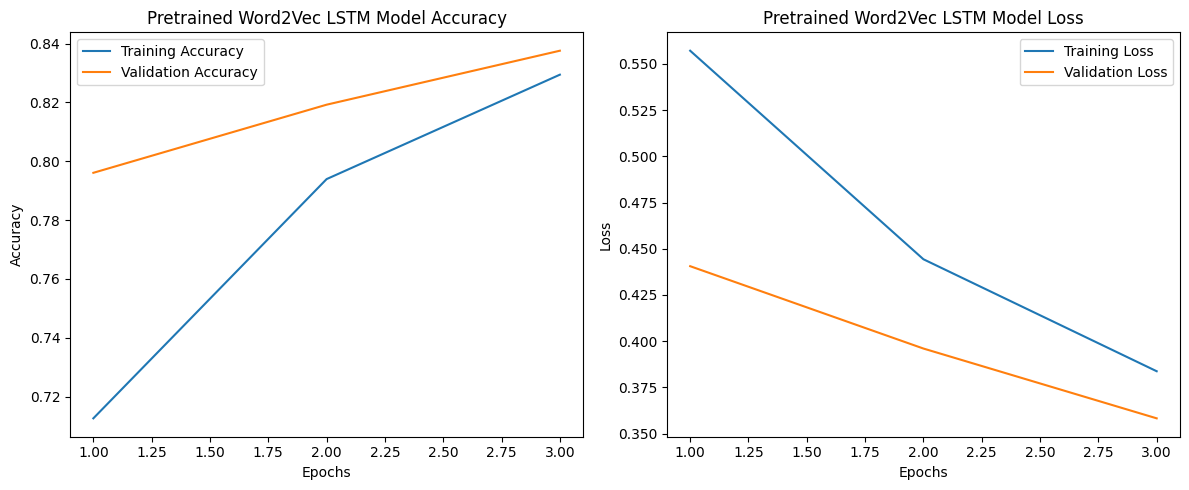

In [ ]:
# Train Model 3: LSTM with pretrained Word2Vec embeddings
print("Training Model 3: Pretrained Embeddings LSTM...")

history3 = model3.fit(
    X_train_padded,
    y_train,

    validation_data=(X_val_padded, y_val),

    epochs=10,
    batch_size=64,

    class_weight=class_weights_dict,

    callbacks=[early_stop, reduce_lr]
)

# Plot training results
plot_history(history3, "Pretrained Word2Vec LSTM Model")

Generating predictions for Model 1: Simple RNN...
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

--- Model 1: Simple RNN: Classification Report ---
               precision    recall  f1-score   support

Not Sarcastic       0.88      0.79      0.83      2997
    Sarcastic       0.79      0.88      0.84      2727

     accuracy                           0.83      5724
    macro avg       0.84      0.84      0.83      5724
 weighted avg       0.84      0.83      0.83      5724



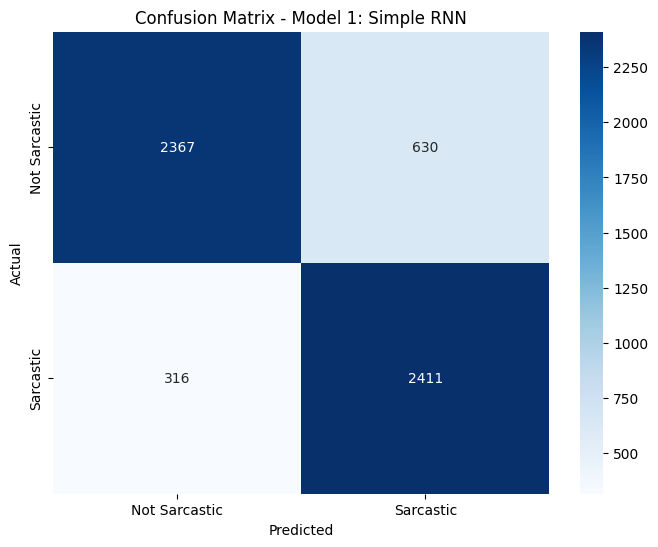

Generating predictions for Model 2: LSTM...
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

--- Model 2: LSTM: Classification Report ---
               precision    recall  f1-score   support

Not Sarcastic       0.87      0.87      0.87      2997
    Sarcastic       0.86      0.85      0.85      2727

     accuracy                           0.86      5724
    macro avg       0.86      0.86      0.86      5724
 weighted avg       0.86      0.86      0.86      5724



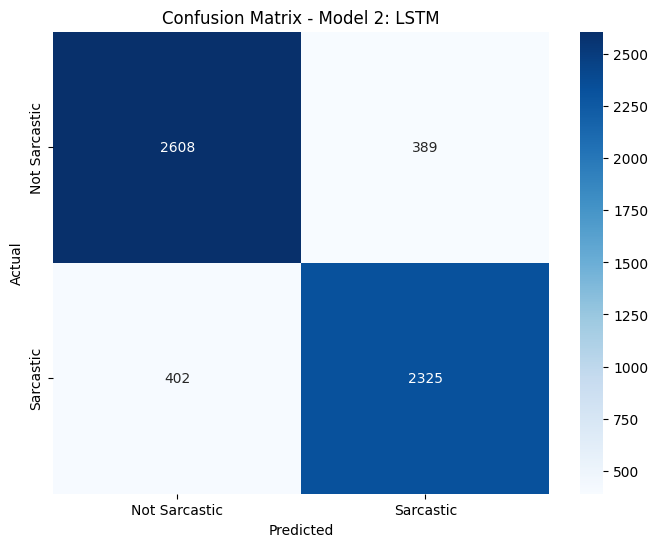

Generating predictions for Model 3: Word2Vec LSTM...
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

--- Model 3: Word2Vec LSTM: Classification Report ---
               precision    recall  f1-score   support

Not Sarcastic       0.85      0.76      0.80      2997
    Sarcastic       0.76      0.86      0.81      2727

     accuracy                           0.80      5724
    macro avg       0.81      0.81      0.80      5724
 weighted avg       0.81      0.80      0.80      5724



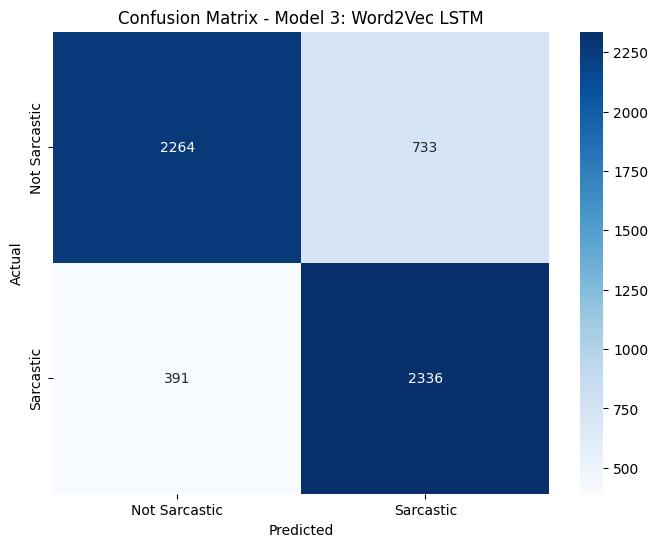

In [ ]:
# Evaluate all models on test set

evaluate_model(rnn_model, X_test_padded, y_test, "Model 1: Simple RNN")

evaluate_model(lstm_model, X_test_padded, y_test, "Model 2: LSTM")

evaluate_model(model3, X_test_padded, y_test, "Model 3: Word2Vec LSTM")

# Error Analysis

### Analyze Misclassified Examples

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def display_misclassified_examples(model, X_test, y_test, model_name, num_examples=3):
    print(f"\n--- Misclassified Examples for {model_name} ---")
    # Predict probabilities on the padded test set
    y_pred_probs = model.predict(X_test_padded)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Create a DataFrame to compare actual and predicted labels
    results_df = pd.DataFrame({
        'text': X_test,
        'actual_label': y_test,
        'predicted_label': y_pred
    })

    # Filter for misclassified examples
    misclassified_df = results_df[results_df['actual_label'] != results_df['predicted_label']]

    if not misclassified_df.empty:
        print(f"Found {len(misclassified_df)} misclassified examples. Displaying the first {num_examples}:")
        # Map numeric labels to 'Not Sarcastic' and 'Sarcastic'
        label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}
        misclassified_df['actual_label_str'] = misclassified_df['actual_label'].map(label_map)
        misclassified_df['predicted_label_str'] = misclassified_df['predicted_label'].map(label_map)

        display(misclassified_df[['text', 'actual_label_str', 'predicted_label_str']].head(num_examples))
    else:
        print("No misclassified examples found (or model is perfect on test set).")

# Display misclassified examples for the LSTM model (as it showed better performance)
display_misclassified_examples(lstm_model, X_test, y_test, "LSTM Model")



--- Misclassified Examples for LSTM Model ---
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
Found 791 misclassified examples. Displaying the first 3:


/tmp/ipykernel_1254/1084289681.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  misclassified_df['actual_label_str'] = misclassified_df['actual_label'].map(label_map)
/tmp/ipykernel_1254/1084289681.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  misclassified_df['predicted_label_str'] = misclassified_df['predicted_label'].map(label_map)


,text,actual_label_str,predicted_label_str
16746,democratic congressman protests trumps environ...,Sarcastic,Not Sarcastic
18542,rex tillerson calls reports of his ouster laug...,Not Sarcastic,Sarcastic
26554,prayers answered by random series of events in...,Sarcastic,Not Sarcastic


### Evaluate Model Complexity vs. Performance

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Create a dictionary of models to evaluate
models_to_evaluate = {
    "Simple RNN": rnn_model,
    "Bidirectional LSTM": lstm_model,
    "Word2Vec LSTM": model3
}

performance_metrics = []

for name, model in models_to_evaluate.items():
    if model is not None:
        y_pred_probs = model.predict(X_test_padded)
        y_pred = np.argmax(y_pred_probs, axis=1)

        accuracy = accuracy_score(y_test, y_pred)
        # Use zero_division=0 to avoid warnings for classes with no predicted samples
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

        performance_metrics.append({
            "Model": name,
            "Accuracy": accuracy,
            "F1 Score": f1,
            "Precision": precision,
            "Recall": recall
        })

# Display the comparison table
performance_df = pd.DataFrame(performance_metrics)
print("\n--- Model Performance Comparison ---")
display(performance_df.round(4))


179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

--- Model Performance Comparison ---


,Model,Accuracy,F1 Score,Precision,Recall
0,Simple RNN,0.8347,0.8347,0.8396,0.8347
1,Bidirectional LSTM,0.8618,0.8618,0.8618,0.8618
2,Word2Vec LSTM,0.8036,0.8035,0.8091,0.8036


### Explain Possible Reasons for Error

Sarcasm detection is a difficult task because it depends heavily on context, tone, and implied meaning, which basic RNN and LSTM models often fail to fully capture. Even though LSTM improves sequence understanding, some sarcastic patterns are still too subtle or ambiguous for the model.

One limitation is the short sequence length (maxlen = 15), which may not provide enough context for certain sentences. Some headlines may also be inherently ambiguous, making them hard to classify even for humans. In addition, removing certain words during preprocessing may slightly reduce important contextual meaning.

Although Word2Vec embeddings help the model understand word relationships better, they are still not as powerful as modern transformer-based models for capturing deep contextual meaning.

### Suggest Potential Improvements
To improve the sarcasm detection models, a few upgrades can be made. First, increasing maxlen (e.g., 20–30) would help the model capture more context, which is often important for understanding sarcasm.
Better preprocessing can also help, such as handling emojis, slang, and internet-style text, since these often carry sarcastic meaning. More advanced NLP techniques or sentiment-based features could also improve understanding.
A major improvement would be using transformer models like BERT or RoBERTa, which are much better at understanding context compared to RNNs and LSTMs. These models usually perform significantly better on tasks like sarcasm detection.
Other improvements include using ensemble methods (combining multiple models), doing better hyperparameter tuning, and applying data augmentation to improve generalization.

## 4.5.5 GUI for Real Time Prediction

In [ ]:
!pip install -q gradio
import gradio as gr

In [ ]:
def predict_sarcasm(input_text):
    # 1. Clean the input text using the existing clean_text function
    cleaned_text = clean_text(input_text)

    # 2. Tokenize the cleaned text
    # texts_to_sequences expects a list of texts
    seq = tokenizer.texts_to_sequences([cleaned_text])

    # 3. Pad the sequence to the defined maxlen
    padded_seq = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')

    # 4. Predict using the best performing model (LSTM model)
    # Make sure the model is loaded or accessible in the global scope
    prediction = lstm_model.predict(padded_seq)

    # 5. Get the class label (0 or 1)
    predicted_class = np.argmax(prediction, axis=1)[0]

    # 6. Map to 'Not Sarcastic' or 'Sarcastic'
    if predicted_class == 1:
        return "Sarcastic"
    else:
        return "Not Sarcastic"

In [ ]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 15, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 256)            │       234,496 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753,224 (10.50 MB)

 Trainable params: 251,074 (980.76 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

 Optimizer params: 502,150 (1.92 MB)

In [ ]:
# Create the Gradio Interface
interface = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(lines=2, placeholder="Enter a headline here..."),
    outputs="text",
    title="Sarcasm Detector",
    description="Enter a news headline to predict if it's sarcastic or not."
)

# Launch the interface
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d4d42b2e47e1cb28e1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
